<a href="https://colab.research.google.com/github/PaolinaCastany/Master_Thesis/blob/main/ThesisPart3_rewrite_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis — Part 3

Genre-specific models (regression + classification) with:
- features consistent with Part 2 (includes `year` when available)
- regression trained on `log1p(popularity)` and predictions clipped to valid range
- all outputs saved automatically

Figures saved:
- 13_genre_regression_performance.png
- 14_genre_classification_performance.png
- 15_feature_importance_heatmap.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle

BASE_FOLDER = "/content/drive/MyDrive/Thesis_Music_Success"
PATHS = {
    'data': os.path.join(BASE_FOLDER, 'data'),
    'plots': os.path.join(BASE_FOLDER, 'plots'),
    'results': os.path.join(BASE_FOLDER, 'results'),
    'models': os.path.join(BASE_FOLDER, 'models')
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("Folders ready.")


Mounted at /content/drive
Folders ready.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score

sns.set_style("whitegrid")

def save_data(df, filename):
    fp = os.path.join(PATHS['results'], filename)
    df.to_csv(fp, index=False)
    print("✅ Saved:", fp)

def save_model(obj, filename):
    fp = os.path.join(PATHS['models'], filename)
    with open(fp, 'wb') as f:
        pickle.dump(obj, f)
    print("✅ Saved model:", fp)

def save_plot(filename):
    fp = os.path.join(PATHS['plots'], filename)
    plt.tight_layout()
    plt.savefig(fp, dpi=300, bbox_inches='tight')
    print("✅ Saved plot:", fp)


In [ ]:
# Load datasets
df_train = pd.read_csv(os.path.join(PATHS['data'], 'spotify_train.csv'))
df_test  = pd.read_csv(os.path.join(PATHS['data'], 'spotify_test.csv'))

if 'genre' not in df_train.columns:
    raise ValueError("Expected a 'genre' column in the train/test datasets.")

audio_features = [
    'danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo'
]
audio_features = [c for c in audio_features if c in df_train.columns]
if 'duration_mins' in df_train.columns:
    audio_features.append('duration_mins')

# Keep year as numeric feature if present
if 'year' in df_train.columns and 'year' not in audio_features:
    audio_features = audio_features + ['year']

print("Features used (per genre):", audio_features)

genres = sorted(df_train['genre'].dropna().unique().tolist())
print("Genres:", genres)


Features used (per genre): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_mins', 'year']
Genres: ['acoustic', 'alt-rock', 'ambient', 'black-metal', 'emo', 'gospel', 'indian', 'k-pop']


In [ ]:
def clip_pred_log(pred_log):
    return np.clip(pred_log, 0.0, np.log1p(100.0))

MIN_TRAIN = 2000
MIN_TEST  = 400

genre_results_reg = []
genre_results_clf = []
fi_rows = []


In [ ]:
for g in tqdm(genres, desc="Genre models", unit="genre"):
    tr = df_train[df_train['genre'] == g].copy()
    te = df_test[df_test['genre'] == g].copy()

    if len(tr) < MIN_TRAIN or len(te) < MIN_TEST:
        continue

    Xtr = tr[audio_features]
    Xte = te[audio_features]

    ytr_raw = tr['popularity'].values
    yte_raw = te['popularity'].values
    ytr_log = np.log1p(ytr_raw)
    yte_log = np.log1p(yte_raw)

    ytr_clf = tr['is_hit'].values
    yte_clf = te['is_hit'].values

    prep = ColumnTransformer(
        transformers=[('num', StandardScaler(), audio_features)],
        remainder='drop'
    )

    # Regression (RF)
    rf_reg = Pipeline(steps=[
        ('prep', prep),
        ('model', RandomForestRegressor(
            n_estimators=250,
            max_depth=20,
            min_samples_leaf=5,
            max_features="sqrt",
            bootstrap=True,
            max_samples=0.7,
            random_state=42,
            n_jobs=-1
        ))
    ])

    t0 = time.time()
    rf_reg.fit(Xtr, ytr_log)
    pred_log = rf_reg.predict(Xte)
    pred_log = clip_pred_log(pred_log)
    pred_raw = np.expm1(pred_log)
    elapsed = time.time() - t0

    mae = mean_absolute_error(yte_raw, pred_raw)
    r2l = r2_score(yte_log, pred_log)

    genre_results_reg.append({"genre": g, "MAE": mae, "R2_log": r2l, "train_seconds": elapsed})
    save_model(rf_reg, f"genre_{g}_rf_reg.pkl")

    rf_reg_model = rf_reg.named_steps['model']
    for feat, imp in zip(audio_features, rf_reg_model.feature_importances_):
        fi_rows.append({"genre": g, "feature": feat, "importance": imp})

    # Classification (RF)
    rf_clf = Pipeline(steps=[
        ('prep', prep),
        ('model', RandomForestClassifier(
            n_estimators=220,
            max_depth=14,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        ))
    ])

    t0 = time.time()
    rf_clf.fit(Xtr, ytr_clf)
    proba = rf_clf.predict_proba(Xte)[:, 1]
    elapsed = time.time() - t0

    auc = roc_auc_score(yte_clf, proba)

    genre_results_clf.append({"genre": g, "ROC_AUC": auc, "train_seconds": elapsed})
    save_model(rf_clf, f"genre_{g}_rf_clf.pkl")

genre_reg_df = pd.DataFrame(genre_results_reg).sort_values("MAE")
genre_clf_df = pd.DataFrame(genre_results_clf).sort_values("ROC_AUC", ascending=False)
fi_df = pd.DataFrame(fi_rows)

save_data(genre_reg_df, "genre_regression_results.csv")
save_data(genre_clf_df, "genre_classification_results.csv")
save_data(fi_df, "genre_feature_importance_long.csv")

display(genre_reg_df.head(10))
display(genre_clf_df.head(10))


Genre models:   0%|          | 0/8 [00:00<?, ?genre/s]

✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_acoustic_rf_reg.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_acoustic_rf_clf.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_alt-rock_rf_reg.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_alt-rock_rf_clf.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_ambient_rf_reg.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_ambient_rf_clf.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_black-metal_rf_reg.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_black-metal_rf_clf.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_emo_rf_reg.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_emo_rf_clf.pkl
✅ Saved model: /content/drive/MyDrive/Thesis_Music_Success/models/genre_gospel_rf_reg.

,genre,MAE,R2_log,train_seconds
3,black-metal,6.583070,0.029756,11.195040
4,emo,7.485560,0.030105,10.968283
1,alt-rock,7.659251,-0.035819,10.770139
2,ambient,8.659270,0.004810,8.773856
0,acoustic,9.568343,-0.024058,14.642720
5,gospel,9.902792,0.040331,8.207220
7,k-pop,10.918264,0.054407,10.971824
6,indian,14.997906,-0.509289,9.707553


,genre,ROC_AUC,train_seconds
5,gospel,0.804665,9.027812
2,ambient,0.720382,8.801546
6,indian,0.719573,4.773981
0,acoustic,0.707767,15.652860
4,emo,0.625589,9.618091
7,k-pop,0.569793,7.438114
1,alt-rock,0.561370,12.150237
3,black-metal,0.478821,2.648300


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/13_genre_regression_performance.png


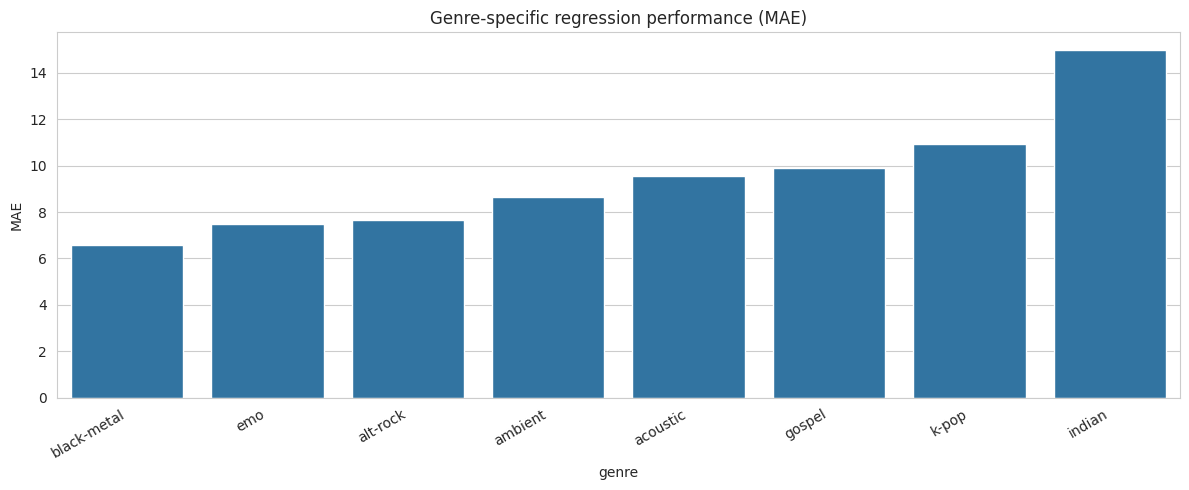

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=genre_reg_df, x="genre", y="MAE")
plt.xticks(rotation=30, ha='right')
plt.title("Genre-specific regression performance (MAE)")
save_plot('13_genre_regression_performance.png')
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/14_genre_classification_performance.png


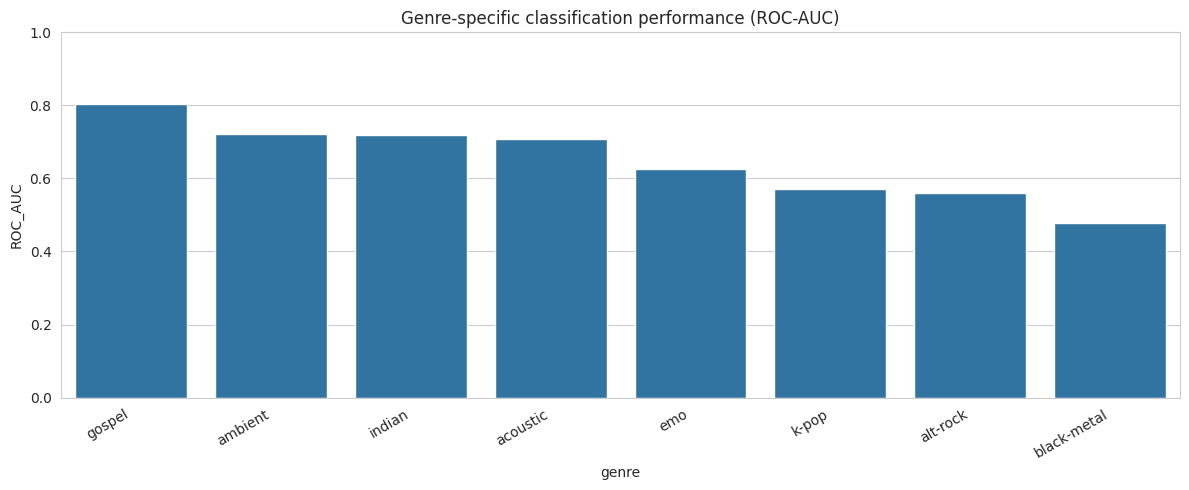

In [ ]:
plt.figure(figsize=(12,5))
sns.barplot(data=genre_clf_df, x="genre", y="ROC_AUC")
plt.xticks(rotation=30, ha='right')
plt.ylim(0,1)
plt.title("Genre-specific classification performance (ROC-AUC)")
save_plot('14_genre_classification_performance.png')
plt.show()


✅ Saved plot: /content/drive/MyDrive/Thesis_Music_Success/plots/15_feature_importance_heatmap.png


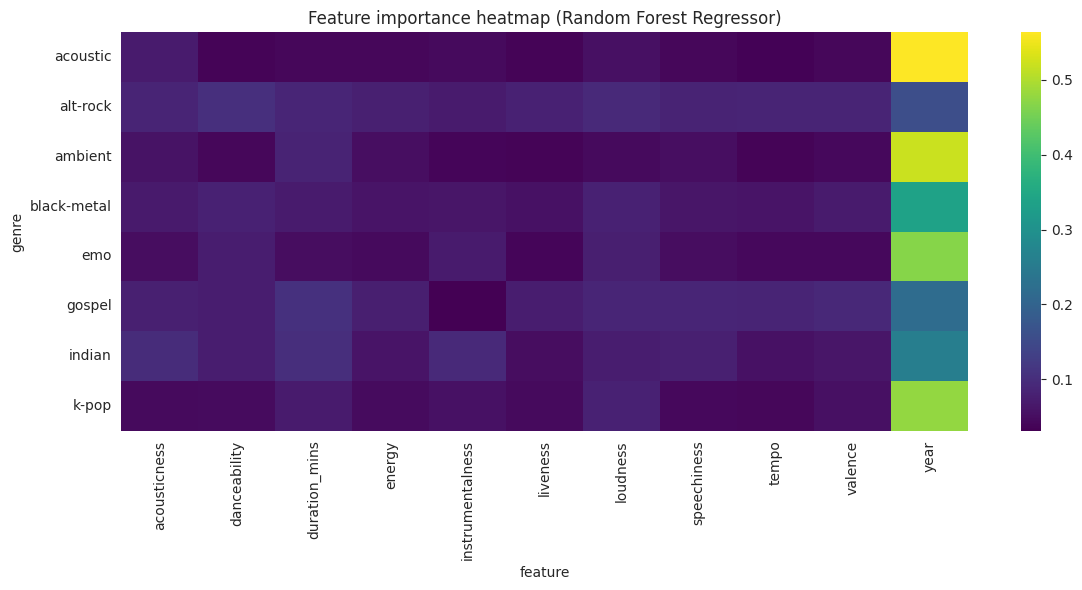

In [ ]:
pivot = fi_df.pivot_table(index="genre", columns="feature", values="importance", aggfunc="mean").fillna(0.0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="viridis")
plt.title("Feature importance heatmap (Random Forest Regressor)")
save_plot('15_feature_importance_heatmap.png')
plt.show()
